# Which customers are worth keeping? Revenue, RFM and forward-looking value for a UK online wholesaler (v2)

**Version 1** of this project (February 2026, dashboard added July 2026) reported £8.9M of revenue from
4,338 customers and an RFM segmentation in which 14% of customers ("Champions") bring 51% of revenue
and 646 "at risk" customers hold £1.04M of past spend.

This notebook re-checks every one of those numbers, then asks the question RFM only gestures at:
**who will actually buy in the next quarter, and is a statistical model better at answering that
than the RFM scores themselves?**

**Plan**
1. Reproduce v1
2. A cleaning ledger: what each rule does to revenue
3. Corrected KPIs and the monthly trend
4. How concentrated is revenue?
5. RFM on clean data, and do the segments predict anything?
6. Cohorts: how fast do new customers come back?
7. Forward-looking value: BG/NBD and Gamma-Gamma from their likelihoods
8. A ranking contest on a held-out quarter
9. Conclusions and limits

In [1]:
import json
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.ensemble import HistGradientBoostingRegressor

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import retail as rt  # noqa: E402

FIG = ROOT / "results" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SEED = 20261007
R = {}
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 160, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})
INK, ACCENT, WARM, GREY = "#1F3A5F", "#2A9D8F", "#C8553D", "#8A8A8A"


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIG / name, bbox_inches="tight")

## 1. Reproduce v1

The [UCI Online Retail dataset](https://archive.ics.uci.edu/dataset/352/online+retail) (Chen, Sain and
Guo 2012; CC BY 4.0) holds every line of every invoice of a UK-based online gift wholesaler from
1 December 2010 to 9 December 2011. Many customers are themselves retailers.

In [2]:
df = rt.load(ROOT / "Online Retail.xlsx")
df["Line"] = df["Quantity"] * df["UnitPrice"]
v1 = rt.v1_clean(df)
R["raw_rows"], R["first_day"], R["last_day"] = len(df), str(df["InvoiceDate"].min().date()), str(df["InvoiceDate"].max().date())
R["v1_revenue"] = float(v1["TotalPrice"].sum())
R["v1_orders"], R["v1_customers"] = int(v1["InvoiceNo"].nunique()), int(v1["CustomerID"].nunique())
R["v1_aov"] = float(v1.groupby("InvoiceNo")["TotalPrice"].sum().mean())
ref = df["InvoiceDate"].max() + pd.Timedelta(days=1)
v1_seg = rt.rfm_segments(rt.rfm_table(v1, ref, "TotalPrice"))
v1_tab = v1_seg.groupby("Segment").agg(customers=("Monetary", "size"), revenue=("Monetary", "sum"))
v1_tab["revenue_share"] = v1_tab["revenue"] / v1_tab["revenue"].sum()
print(f"{R['raw_rows']:,} rows, {R['first_day']} to {R['last_day']}")
print(f"v1: revenue £{R['v1_revenue']:,.2f}, {R['v1_orders']:,} orders, {R['v1_customers']:,} customers, AOV £{R['v1_aov']:.2f}")
print(v1_tab.round(3).to_string())

541,909 rows, 2010-12-01 to 2011-12-09
v1: revenue £8,911,407.90, 18,532 orders, 4,338 customers, AOV £480.87
                  customers      revenue  revenue_share
Segment                                                
At risk                 646  1040932.691          0.117
Champions               609  4578426.310          0.514
Hibernating            1504   767146.842          0.086
Loyal                   914  2022948.841          0.227
Recent / one-off        665   501953.220          0.056


Every v1 number reproduces. v1's cleaning kept lines with a customer ID, a positive quantity and a
positive price, and dropped invoices starting with "C" (cancellations). That last rule is the problem:
**dropping a cancellation does not remove the purchase it cancels.**

## 2. A cleaning ledger: what each rule does to revenue

In [3]:
lines, unmatched, service, ledger = rt.ledger_clean(df)
ledger["gross_sales_m"] = ledger["gross_sales"] / 1e6
print(ledger[["step", "rows", "rows_removed", "value_removed", "gross_sales_m"]].round(3).to_string(index=False))
R["clean_revenue"] = float(lines["Value"].sum())
R["clean_customers"] = int(lines["CustomerID"].nunique())
R["cancellations_netted_value"] = float(-ledger.loc[ledger["step"].str.startswith("net cancellations"), "value_removed"].iloc[0])
R["manual_corrections_value"] = float(-ledger.loc[ledger["step"].str.startswith("net manual"), "value_removed"].iloc[0])
R["service_value"] = float(service.loc[service["Line"] > 0, "Line"].sum())
R["duplicates_removed"] = int(ledger.loc[ledger["step"].str.startswith("drop exact"), "rows_removed"].iloc[0])
R["unmatched_cancellations"] = len(unmatched)
R["unmatched_cancellations_value"] = float((unmatched["Quantity"] * unmatched["UnitPrice"]).sum())
R["no_id_rows"] = int(ledger.loc[1, "rows_removed"])
R["no_id_value"] = float(ledger.loc[1, "value_removed"])
print(f"\nnet merchandise revenue from identified customers: £{R['clean_revenue']:,.2f} ({R['clean_customers']:,} customers)")
print(f"v1 overstated it by £{R['v1_revenue'] - R['clean_revenue']:,.0f} ({(R['v1_revenue'] / R['clean_revenue'] - 1):.1%})")

                                                       step   rows  rows_removed  value_removed  gross_sales_m
                                                   raw file 541909             0          0.000         10.667
                            drop rows without a customer ID 406829        135080    1447682.120          8.911
                                  drop exact duplicate rows 401604          5225      21546.390          8.887
                                      drop zero-price lines 401564            40          0.000          8.887
                    set aside postage, fees and adjustments 399656          1908      13042.494          8.737
       net cancellations against the purchases they reverse 388370          8506    -447847.870          8.289
net manual corrections that exactly reverse a same-day line 388363             7     -39007.610          8.250

net merchandise revenue from identified customers: £8,250,372.16 (4,324 customers)
v1 overstated it by £661,036

The ledger starts from the raw file's £10.67M of positive lines. Rows without a customer ID (135,080,
worth £1.45M) cannot be attributed to anyone, so like v1 this analysis leaves them out of the customer
view. The steps v1 skipped are the last four: 5,225 exact duplicate rows, postage and fees, and, the big
one, **cancellations that were dropped instead of netted**. Net merchandise revenue from identified
customers is **£8,250,372**, so v1's £8.91M overstated it by £661,036, or 8.0%.

{'duplicates': 24199.01, 'service_lines': 149981.25, 'cancelled_purchases': 447847.87, 'manual_corrections': 39007.61, 'residual': -0.0}


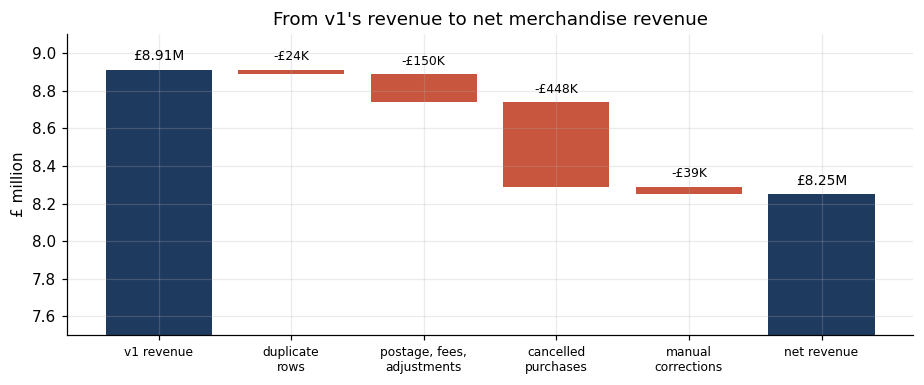

In [4]:
# Bridge from v1's figure to net revenue. v1 summed positive lines with a customer ID and a positive
# price, so each bar below is the part of that sum a cleaning step removes.
d_id = df[df["CustomerID"].notna() & (df["UnitPrice"] > 0)]
dup = df[df["CustomerID"].notna()].duplicated().reindex(d_id.index)
dup_pos = float(d_id.loc[dup & (d_id["Line"] > 0), "Line"].sum())
svc_pos = float(d_id.loc[~dup & d_id["StockCode"].isin(rt.NON_MERCH) & (d_id["Line"] > 0), "Line"].sum())
residual = R["v1_revenue"] - dup_pos - svc_pos - R["cancellations_netted_value"] - R["manual_corrections_value"] - R["clean_revenue"]
R["bridge"] = {"duplicates": dup_pos, "service_lines": svc_pos, "cancelled_purchases": R["cancellations_netted_value"],
               "manual_corrections": R["manual_corrections_value"], "residual": residual}
print({k: round(v, 2) for k, v in R["bridge"].items()})
fig, ax = plt.subplots(figsize=(8.5, 3.6))
steps = ["v1 revenue", "duplicate\nrows", "postage, fees,\nadjustments", "cancelled\npurchases", "manual\ncorrections", "net revenue"]
vals = [R["v1_revenue"], -dup_pos, -svc_pos, -R["cancellations_netted_value"], -R["manual_corrections_value"], R["clean_revenue"]]
level = R["v1_revenue"]
for i, (s, v) in enumerate(zip(steps, vals)):
    if i in (0, len(steps) - 1):
        ax.bar(i, v / 1e6, color=INK)
        ax.text(i, v / 1e6 + 0.05, f"£{v / 1e6:.2f}M", ha="center", fontsize=9)
    else:
        ax.bar(i, v / 1e6, bottom=level / 1e6, color=WARM)
        ax.text(i, level / 1e6 + 0.05, f"-£{-v / 1e3:,.0f}K", ha="center", fontsize=8)
        level += v
ax.set_xticks(range(len(steps)), steps, fontsize=8)
ax.set_ylim(7.5, 9.1)
ax.set_ylabel("£ million")
ax.set_title("From v1's revenue to net merchandise revenue")
save(fig, "revenue_waterfall.png")

The bridge closes to the penny (residual £0.00): £24,199 of duplicate rows, £149,981 of postage, fees
and adjustments, £447,848 of purchases that were later cancelled, and £39,008 of mis-keyed lines that a
manual entry reversed.

### The orders that never happened

The three customers below are the clearest cases. Each placed a huge order and reversed it minutes
later; v1 counted the order and ignored the reversal.

In [5]:
cases = []
for cid in (16446, 12346, 15098):
    d = df[df["CustomerID"] == cid].sort_values("InvoiceDate")
    big = d[d["Line"] > 0].nlargest(1, "Line").iloc[0]
    cases.append({"customer": cid, "largest line": f"{int(big.Quantity):,} x {big.Description} at £{big.UnitPrice:.2f}",
                  "when": str(big.InvoiceDate), "v1 spend": float(v1.loc[v1["CustomerID"] == cid, "TotalPrice"].sum()),
                  "net spend": float(lines.loc[lines["CustomerID"] == cid, "Value"].sum())})
cases = pd.DataFrame(cases)
print(cases.to_string(index=False))
R["phantom_value"] = float(cases["v1 spend"].sum() - cases["net spend"].sum())
v1_rank = v1.groupby("CustomerID")["TotalPrice"].sum().rank(ascending=False)
R["phantom_v1_ranks"] = {int(c): int(v1_rank[c]) for c in cases["customer"]}
print("their rank among v1's top spenders:", R["phantom_v1_ranks"])

 customer                                     largest line                when  v1 spend  net spend
    16446    80,995 x PAPER CRAFT , LITTLE BIRDIE at £2.08 2011-12-09 09:15:00  168472.5        2.9
    12346 74,215 x MEDIUM CERAMIC TOP STORAGE JAR at £1.04 2011-01-18 10:01:00   77183.6        0.0
    15098   60 x PICNIC BASKET WICKER 60 PIECES at £649.50 2011-06-10 15:28:00   39916.5      649.5
their rank among v1's top spenders: {16446: 4, 12346: 10, 15098: 24}


Three orders worth £284,920 in v1's figures. Customer 16446 ordered 80,995 paper-craft sets on the last
morning of the data and cancelled 12 minutes later; customer 12346 did the same with 74,215 storage
jars in January, and that order is their entire history. In v1 they were the 4th and 10th biggest
customers in the business. Customer 15098 shows why netting has to match on price: they keyed in 60
baskets at £649.50 instead of £4.95, reversed it with a manual line, re-entered one basket correctly and
cancelled the small baskets. Netted properly, they bought one £649.50 basket.

## 3. Corrected KPIs and the monthly trend

net revenue £8,250,372; 18,275 orders; mean order £451.46, median £297.64


peak month 2011-11; November's revenue per trading day is 2.4x February's


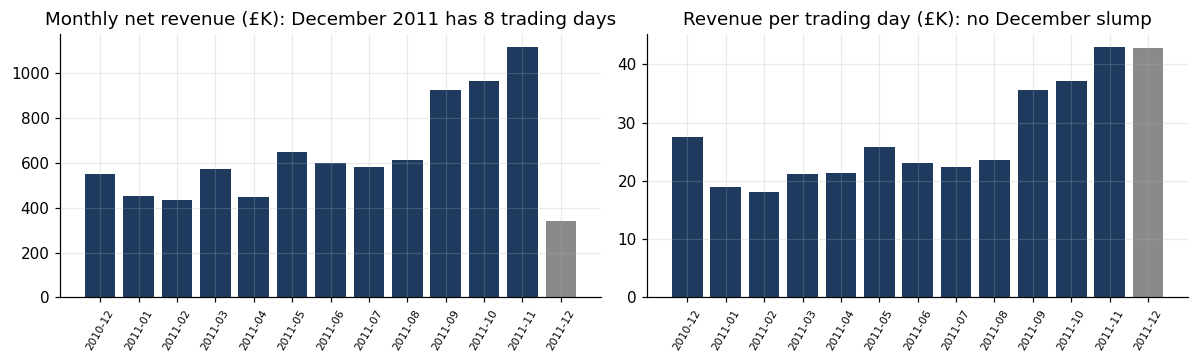

In [6]:
orders = lines.groupby("InvoiceNo")["Value"].sum()
R["clean_orders"], R["clean_aov"] = int(len(orders)), float(orders.mean())
R["clean_aov_median"] = float(orders.median())
monthly = lines.groupby(lines["InvoiceDate"].dt.to_period("M"))["Value"].sum()
days = lines.groupby(lines["InvoiceDate"].dt.to_period("M"))["InvoiceDate"].apply(lambda s: s.dt.date.nunique())
per_day = monthly / days
R["dec2011_trading_days"] = int(days.iloc[-1])
print(f"net revenue £{R['clean_revenue']:,.0f}; {R['clean_orders']:,} orders; mean order £{R['clean_aov']:.2f}, median £{R['clean_aov_median']:.2f}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
x = [str(p) for p in monthly.index]
axes[0].bar(x, monthly / 1e3, color=[INK] * (len(x) - 1) + [GREY])
axes[0].set_title("Monthly net revenue (£K): December 2011 has 8 trading days")
axes[1].bar(x, per_day / 1e3, color=[INK] * (len(x) - 1) + [GREY])
axes[1].set_title("Revenue per trading day (£K): no December slump")
for ax in axes:
    ax.tick_params(axis="x", rotation=60, labelsize=7)
save(fig, "monthly.png")
R["peak_month"] = str(monthly.idxmax())
R["nov_vs_feb_per_day"] = float(per_day[pd.Period("2011-11")] / per_day[pd.Period("2011-02")])
print(f"peak month {R['peak_month']}; November's revenue per trading day is {R['nov_vs_feb_per_day']:.1f}x February's")

Mean order value is pulled up by wholesale orders; the median order is the better "typical order".
v1's monthly chart ended with a fall in December 2011, which is just a month with 8 trading days. Per
trading day, the business peaks in November, its customers stocking up for Christmas.

## 4. How concentrated is revenue?

In [7]:
cust = lines.groupby("CustomerID")["Value"].sum()
cust = cust.add(unmatched.groupby("CustomerID").apply(lambda u: (u["Quantity"] * u["UnitPrice"]).sum()), fill_value=0)
cust = cust[cust > 0]
pop, cum, gini = rt.lorenz(cust.to_numpy())
R["gini"] = gini
top = cust.sort_values(ascending=False)
for p in (0.01, 0.10, 0.14, 0.20):
    R[f"top{int(p * 100)}_share"] = float(top.iloc[: int(np.ceil(p * len(top)))].sum() / top.sum())
print(f"Gini {gini:.3f}; top 1% {R['top1_share']:.1%}, top 10% {R['top10_share']:.1%}, top 14% {R['top14_share']:.1%}, "
      f"top 20% {R['top20_share']:.1%} of net revenue")

Gini 0.705; top 1% 30.2%, top 10% 60.0%, top 14% 66.4%, top 20% 73.7% of net revenue


Revenue is more concentrated than v1's headline suggested: the top 1% of customers bring 30.2% of net
revenue, the top 10% bring 60.0%, and the Gini coefficient is 0.70. (v1's "14% bring 51%" described
the Champions segment, which is defined by recency and frequency, not spend.) For a wholesaler, this
is the first fact a sales team should know: a few dozen accounts are worth more than thousands of
small ones.
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.plot(pop * 100, cum * 100, color=INK)
ax.plot([0, 100], [0, 100], color=GREY, ls="--")
ax.fill_between(pop * 100, cum * 100, pop * 100, color=INK, alpha=0.08)
ax.set(xlabel="Customers, smallest to largest, %", ylabel="Share of net revenue, %", title=f"Lorenz curve, Gini {gini:.2f}")
save(fig, "lorenz.png")

## 5. RFM on clean data, and do the segments predict anything?

The same quartile rules as v1, on net revenue.

In [8]:
rfm = rt.rfm_table(lines, ref, "Value", unmatched.groupby("CustomerID").apply(lambda u: (u["Quantity"] * u["UnitPrice"]).sum()))
rfm = rfm[rfm["Monetary"] > 0]
seg = rt.rfm_segments(rfm)
tab = seg.groupby("Segment").agg(customers=("Monetary", "size"), revenue=("Monetary", "sum"))
tab["revenue_share"] = tab["revenue"] / tab["revenue"].sum()
comp = v1_tab.join(tab, lsuffix="_v1", rsuffix="_v2")
print(comp.round(3).to_string())
R["segments_v2"] = {s: {"customers": int(r.customers), "revenue": float(r.revenue), "share": float(r.revenue_share)} for s, r in tab.iterrows()}

                  customers_v1   revenue_v1  revenue_share_v1  customers_v2  revenue_v2  revenue_share_v2
Segment                                                                                                  
At risk                    646  1040932.691             0.117           640   908798.63             0.110
Champions                  609  4578426.310             0.514           614  4410139.65             0.536
Hibernating               1504   767146.842             0.086          1504   690578.13             0.084
Loyal                      914  2022948.841             0.227           906  1899475.03             0.231
Recent / one-off           665   501953.220             0.056           657   321693.79             0.039


On clean data the segments barely move in size (Champions 614 instead of 609, At risk 640 instead of
646), but the At-risk group's past spend falls from £1.04M to £0.91M, and Champions now hold 53.6% of
revenue.

RFM labels are descriptions of the past; their value is whether they predict the future. Score every
customer on data up to **9 September 2011**, then look at what each segment did in the next 13 weeks
(10 September to 9 December), which the scoring never saw.

In [9]:
CAL_END, HOLD_END = pd.Timestamp("2011-09-09"), pd.Timestamp("2011-12-09")
HOLD_WEEKS = (HOLD_END - CAL_END).days / 7
tx = rt.daily_transactions(lines)
cal_lines = lines[lines["InvoiceDate"] <= CAL_END + pd.Timedelta(days=1)]
seg_cal = rt.rfm_segments(rt.rfm_table(cal_lines, CAL_END + pd.Timedelta(days=1), "Value"))
hold = tx[(tx["day"] > CAL_END) & (tx["day"] <= HOLD_END)].groupby("CustomerID").agg(days=("day", "size"), spend=("value", "sum"))
seg_cal = seg_cal.join(hold).fillna({"days": 0, "spend": 0})
val = seg_cal.groupby("Segment").agg(customers=("spend", "size"), bought_again=("days", lambda d: (d > 0).mean()),
                                     mean_next_quarter_spend=("spend", "mean"), past_spend=("Monetary", "mean"))
val["next_quarter_share"] = seg_cal.groupby("Segment")["spend"].sum() / seg_cal["spend"].sum()
print(val.round(3).to_string())
R["segment_validation"] = val.round(4).to_dict(orient="index")

                  customers  bought_again  mean_next_quarter_spend  past_spend  next_quarter_share
Segment                                                                                           
At risk                 474         0.584                  422.809     987.375               0.078
Champions               459         0.895                 2826.949    5870.251               0.505
Hibernating            1203         0.369                  226.697     386.958               0.106
Loyal                   748         0.739                  885.757    1660.494               0.258
Recent / one-off        479         0.480                  284.773     499.753               0.053


**The segments do predict, but one label misleads.** Of customers labelled Champions on 9 September,
89.5% bought again within 13 weeks, and they brought half of the next quarter's revenue. But 58.4% of
those labelled **At risk** also bought again, more than the 48.0% of "Recent / one-off" customers. In
this business, a quiet spell is often just the gap between wholesale orders. Calling them at risk is
fine; treating them as lost would be expensive.

## 6. Cohorts: how fast do new customers come back?

Customers grouped by the month of their first purchase; each cell is the share who bought again in a
later month. The December 2010 cohort includes customers acquired before the data starts, so it looks
more loyal than a true cohort of new customers.

month-1 return: Dec 2010 cohort 36.6%, later cohorts average 18.9%


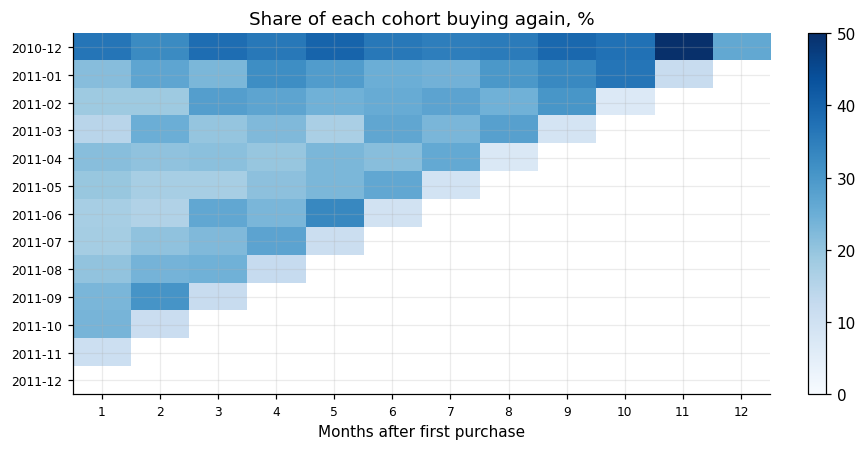

In [10]:
first = tx.groupby("CustomerID")["day"].min().dt.to_period("M").rename("cohort")
act = tx.assign(month=tx["day"].dt.to_period("M")).merge(first, left_on="CustomerID", right_index=True)
act["age"] = (act["month"] - act["cohort"]).apply(lambda d: d.n)
co = act.groupby(["cohort", "age"])["CustomerID"].nunique().unstack()
co = co.div(co[0], axis=0)
fig, ax = plt.subplots(figsize=(8, 4.2))
im = ax.imshow(co.iloc[:, 1:].to_numpy() * 100, cmap="Blues", aspect="auto", vmin=0, vmax=50)
ax.set_yticks(range(len(co)), [str(c) for c in co.index], fontsize=8)
ax.set_xticks(range(co.shape[1] - 1), range(1, co.shape[1]), fontsize=8)
ax.set_xlabel("Months after first purchase")
ax.set_title("Share of each cohort buying again, %")
fig.colorbar(im, ax=ax, fraction=0.03)
save(fig, "cohorts.png")
R["cohort_month1_return_excl_dec2010"] = float(co.iloc[1:, 1].mean())
R["cohort_month1_return_dec2010"] = float(co.iloc[0, 1])
print(f"month-1 return: Dec 2010 cohort {R['cohort_month1_return_dec2010']:.1%}, later cohorts average {R['cohort_month1_return_excl_dec2010']:.1%}")

On average 18.9% of a new month's customers buy again the following month. The December 2010 "cohort"
returns at 36.6%, twice that, because it is not a cohort of new customers: it holds every established
customer whose history simply starts there. This is left-censoring, and it is why the first row of
any cohort chart built from a data extract deserves suspicion.

## 7. Forward-looking value: BG/NBD and Gamma-Gamma

**The idea.** Each customer buys at their own rate while "alive" and may stop for good; we observe
only their purchase days. The BG/NBD model (Fader, Hardie and Lee 2005) makes this precise:

- while alive, purchases follow a Poisson process with rate $\lambda$; across customers
  $\lambda \sim \text{Gamma}(r, \alpha)$;
- after each purchase a customer drops out with probability $p$; across customers
  $p \sim \text{Beta}(a, b)$.

For a customer with $x$ repeat purchase days, the last at time $t_x$, observed for $T$ weeks since the
first, the likelihood is

$$L = \frac{B(a, b+x)}{B(a,b)} \frac{\Gamma(r+x)\,\alpha^r}{\Gamma(r)\,(\alpha+T)^{r+x}}
     + \mathbb{1}_{x>0}\,\frac{B(a+1, b+x-1)}{B(a,b)} \frac{\Gamma(r+x)\,\alpha^r}{\Gamma(r)\,(\alpha+t_x)^{r+x}},$$

maximised over $(r, \alpha, a, b)$ in `src/retail.py` with no library beyond `scipy`. A purchase day is
a day with positive net merchandise spend. The model is fitted on data up to 9 September 2011 and
judged on the 13 weeks after.

In [11]:
s = rt.summarise(tx, CAL_END)
s = s.join(hold).fillna({"days": 0, "spend": 0})
bg = rt.fit_bgnbd(s)
nbd = rt.fit_nbd(s)
R["bgnbd"], R["nbd"] = {k: float(v) for k, v in bg.items() if k != "converged"}, {k: float(v) for k, v in nbd.items() if k != "converged"}
R["calibration_customers"] = len(s)
print(f"{len(s):,} customers with a first purchase by 9 September 2011")
print("BG/NBD:", {k: round(float(v), 4) for k, v in bg.items()})
print("NBD (no dropout):", {k: round(float(v), 4) for k, v in nbd.items()})
print(f"log-likelihood gain from allowing dropout: {nbd['negll'] - bg['negll']:.2f}")

3,363 customers with a first purchase by 9 September 2011
BG/NBD: {'r': 0.7186, 'alpha': 9.4157, 'a': 0.7015, 'b': 22372170.7924, 'negll': 22652.5513, 'converged': 1.0}
NBD (no dropout): {'r': 0.7187, 'alpha': 9.4196, 'negll': 22652.5515, 'converged': 1.0}
log-likelihood gain from allowing dropout: 0.00


The dropout parameters run away ($b$ heads to infinity, so the mean dropout probability
$a/(a+b)$ is effectively zero) and allowing dropout improves the log-likelihood by under one point.
**Within nine months, these wholesale customers show no sign of the "buy, then vanish" pattern the
model is built to find**, and BG/NBD collapses to its no-dropout special case, the NBD model, whose
forecast has a closed form:

$$E[\text{purchase days in the next } t \text{ weeks} \mid x, T] = t\,\frac{r + x}{\alpha + T}.$$

That has a consequence: the forecast depends on how often a customer bought, not on how recently.
Section 8 tests whether that matters.

next 13 weeks: actual 4,441 purchase days, forecast 3,336 (actual / forecast = 1.33)
    days  pred_days
xb                 
0   0.58       0.38
1   0.91       0.72
2   1.20       0.99
3   1.53       1.23
4   1.90       1.50
5   1.99       1.73
6   2.76       2.03
7   2.88       2.25
8   3.55       2.48
9   3.66       2.83
10  6.96       5.01


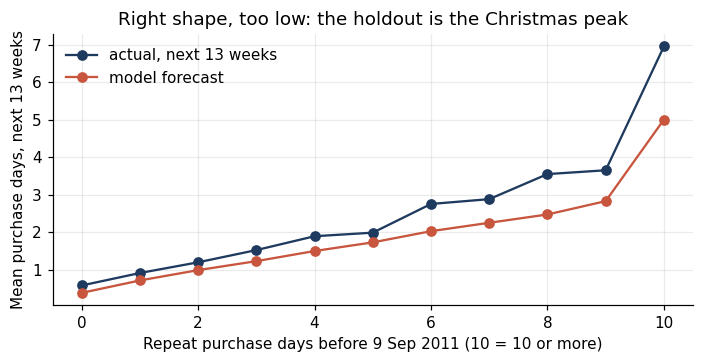

In [12]:
s["pred_days"] = rt.nbd_expected(nbd, HOLD_WEEKS, s["x"], s["T"])
R["holdout_actual_days"], R["holdout_pred_days"] = float(s["days"].sum()), float(s["pred_days"].sum())
cal = s.assign(xb=s["x"].clip(upper=10)).groupby("xb")[["days", "pred_days"]].mean()
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(cal.index, cal["days"], marker="o", color=INK, label="actual, next 13 weeks")
ax.plot(cal.index, cal["pred_days"], marker="o", color=WARM, label="model forecast")
ax.set(xlabel="Repeat purchase days before 9 Sep 2011 (10 = 10 or more)", ylabel="Mean purchase days, next 13 weeks",
       title="Right shape, too low: the holdout is the Christmas peak")
ax.legend(frameon=False)
save(fig, "nbd_calibration.png")
print(f"next 13 weeks: actual {R['holdout_actual_days']:,.0f} purchase days, forecast {R['holdout_pred_days']:,.0f} "
      f"(actual / forecast = {R['holdout_actual_days'] / R['holdout_pred_days']:.2f})")
print(cal.round(2).to_string())

The forecast tracks the shape across frequency groups but sits about a quarter too low everywhere.
That is not a fitting problem: the holdout is September to December, the wholesaler's Christmas peak
(November's revenue per trading day is roughly double February's, Section 3). A model fitted on one
year has no way to learn a seasonal pattern it has seen once. Its *ranking* of customers can still be
useful, and that is what Section 8 measures.

### Gamma-Gamma: what is a purchase day worth?

Spend per purchase day is modelled separately: each customer's purchases have a gamma-distributed
value around their own mean, and those means vary across customers. It assumes a customer's spend
per purchase is unrelated to how often they buy.

In [13]:
rep = s[(s["x"] > 0) & (s["m"] > 0)]
R["gg_corr_x_m"] = float(np.corrcoef(rep["x"], rep["m"])[0, 1])
gg = rt.fit_gg(rep["x"], rep["m"])
R["gg"] = {k: float(v) for k, v in gg.items() if k != "converged"}
R["gg_population_mean"] = float(gg["p"] * gg["gamma"] / (gg["q"] - 1))
s["exp_value"] = rt.expected_value(gg, s["x"], s["m"], fallback=float(rep["m"].mean()))
s["pred_spend"] = s["pred_days"] * s["exp_value"]
print(f"correlation of frequency and spend per purchase: {R['gg_corr_x_m']:.2f} (the independence assumption is reasonable)")
print("Gamma-Gamma:", {k: round(float(v), 3) for k, v in gg.items()}, f"population mean per purchase day £{R['gg_population_mean']:.0f}")

correlation of frequency and spend per purchase: 0.10 (the independence assumption is reasonable)
Gamma-Gamma: {'p': 2.431, 'q': 3.308, 'gamma': 378.538, 'negll': 13183.588, 'converged': 1.0} population mean per purchase day £399


Frequency and spend per purchase day are nearly unrelated (correlation 0.10), so the model's key
assumption holds. A purchase day is worth £399 on average across the population; each customer's
expected value is pulled from their own average toward that figure, more strongly when they have few
purchases.

## 8. A ranking contest on a held-out quarter

The business question: on 9 September, rank customers for a retention campaign. Who will spend in
the next 13 weeks? Four contenders, all scored on data up to 9 September only:

1. **Past spend** (the simplest possible rule);
2. **RFM score** (R + F + M quartile scores, as v1 built them);
3. **NBD x Gamma-Gamma** expected spend (Section 7);
4. **Gradient-boosted trees** trained on an earlier window: features on 10 June 2011, target = spend in
   the 13 weeks to 9 September; then applied to features on 9 September.

In [14]:
ORIGIN1 = CAL_END - pd.Timedelta(days=91)
f1 = rt.features_at(tx, lines, ORIGIN1)
y1 = tx[(tx["day"] > ORIGIN1) & (tx["day"] <= CAL_END)].groupby("CustomerID")["value"].sum()
f1["target"] = y1.reindex(f1.index).fillna(0)
FEATS = ["x", "t_x", "T", "gap", "spend", "mean_value", "max_value", "products", "uk", "last90_spend"]
gbm = HistGradientBoostingRegressor(loss="poisson", max_iter=300, learning_rate=0.05, max_leaf_nodes=15, random_state=SEED)
gbm.fit(f1[FEATS].fillna(0), f1["target"])
f2 = rt.features_at(tx, lines, CAL_END)
s["ml_spend"] = pd.Series(gbm.predict(f2[FEATS].fillna(0)), index=f2.index).reindex(s.index)
s["past_spend"] = f2["spend"].reindex(s.index)
sc = seg_cal[["R", "F", "M"]].sum(axis=1)
s["rfm_score"] = sc.reindex(s.index) + 1e-6 * s["past_spend"]  # break ties by past spend

y = s["spend"].to_numpy()
rows = []
for name, col in (("past spend", "past_spend"), ("RFM score", "rfm_score"), ("NBD x Gamma-Gamma", "pred_spend"),
                  ("gradient-boosted trees", "ml_spend")):
    rows.append({"method": name, "spearman": spearmanr(s[col], y)[0], "top10_capture": rt.capture(y, s[col], 0.10),
                 "top20_capture": rt.capture(y, s[col], 0.20),
                 "forecast_total": float(s[col].sum()) if col in ("pred_spend", "ml_spend") else np.nan})
contest = pd.DataFrame(rows)
contest.to_csv(ROOT / "results" / "ranking_contest.csv", index=False)
R["contest"] = contest.set_index("method").round(4).to_dict(orient="index")
R["holdout_actual_spend"] = float(y.sum())
R["holdout_best_possible_top20"] = rt.capture(y, y, 0.20)
print(contest.round(3).to_string(index=False))
print(f"actual next-quarter spend £{y.sum():,.0f}; a perfect ranking's top 20% would hold {R['holdout_best_possible_top20']:.1%}")

                method  spearman  top10_capture  top20_capture  forecast_total
            past spend     0.527          0.561          0.677             NaN
             RFM score     0.526          0.481          0.651             NaN
     NBD x Gamma-Gamma     0.512          0.559          0.693     1532456.479
gradient-boosted trees     0.508          0.560          0.673     1878269.948
actual next-quarter spend £2,569,650; a perfect ranking's top 20% would hold 81.2%


**The simplest rule is about as good as the models.** Ranking by past spend gives a Spearman correlation
of 0.53 with next-quarter spend; the NBD x Gamma-Gamma model 0.51, the gradient-boosted trees 0.51. If
the campaign can reach 20% of customers, past spend captures 67.7% of next-quarter spend, the
probabilistic model 69.3% and the trees 67.3%, against 81.2% for perfect foresight. The RFM score is
the weakest at the top of the list (48.1% captured by its top 10%), because it caps spend at a quartile
and so cannot tell a £2,000 customer from a £200,000 one.

So the models' extra value here is not ranking: it is a *forecast in units*: purchase days and pounds,
which past spend cannot give. And those forecasts are low for the seasonal reason in Section 7 (the
model expected £1.53M; customers spent £2.57M).

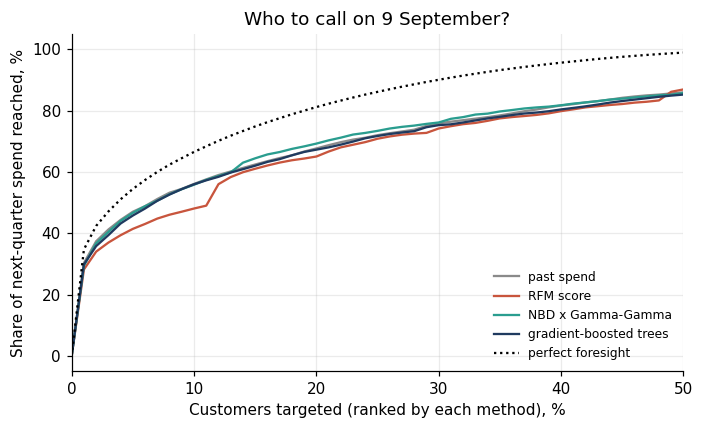

In [15]:
fig, ax = plt.subplots(figsize=(6.5, 4))
fr = np.linspace(0, 1, 101)
for (name, col), c in zip((("past spend", "past_spend"), ("RFM score", "rfm_score"), ("NBD x Gamma-Gamma", "pred_spend"),
                           ("gradient-boosted trees", "ml_spend")), (GREY, WARM, ACCENT, INK)):
    ax.plot(fr * 100, [rt.capture(y, s[col], f) * 100 if f > 0 else 0 for f in fr], color=c, label=name)
ax.plot(fr * 100, [rt.capture(y, y, f) * 100 if f > 0 else 0 for f in fr], color="black", ls=":", label="perfect foresight")
ax.set(xlim=(0, 50), xlabel="Customers targeted (ranked by each method), %", ylabel="Share of next-quarter spend reached, %",
       title="Who to call on 9 September?")
ax.legend(frameon=False, fontsize=8)
save(fig, "ranking_contest.png")

## 9. Scoring today's customers

Refit on all data to 9 December 2011 and score every customer: expected purchase days and spend in the
next 13 weeks (a ranking, not a forecast of the total, for the seasonal reason above), next to v1's
segment labels on clean data.

In [16]:
s_all = rt.summarise(tx, pd.Timestamp("2011-12-09"))
nbd_all = rt.fit_nbd(s_all)
rep_all = s_all[(s_all["x"] > 0) & (s_all["m"] > 0)]
gg_all = rt.fit_gg(rep_all["x"], rep_all["m"])
s_all["exp_spend"] = rt.nbd_expected(nbd_all, 13, s_all["x"], s_all["T"]) * rt.expected_value(gg_all, s_all["x"], s_all["m"], float(rep_all["m"].mean()))
f3 = rt.features_at(tx, lines, pd.Timestamp("2011-12-09"))
f2["target"] = s["spend"].reindex(f2.index).fillna(0)
gbm2 = HistGradientBoostingRegressor(loss="poisson", max_iter=300, learning_rate=0.05, max_leaf_nodes=15, random_state=SEED)
gbm2.fit(f2[FEATS].fillna(0), f2["target"])
s_all["ml_spend"] = pd.Series(gbm2.predict(f3[FEATS].fillna(0)), index=f3.index).reindex(s_all.index)
scored = seg.join(s_all[["exp_spend", "ml_spend"]], how="left")
scored["ml_rank_top20"] = scored["ml_spend"].rank(ascending=False, pct=True) <= 0.20
by = scored.groupby("Segment").agg(customers=("Monetary", "size"), past_revenue=("Monetary", "sum"),
                                   in_model_top20=("ml_rank_top20", "sum"), expected_spend_ml=("ml_spend", "sum"))
by["share_of_expected"] = by["expected_spend_ml"] / by["expected_spend_ml"].sum()
print(by.round(3).to_string())
R["scored_segments"] = by.round(3).to_dict(orient="index")
scored[["Recency", "Frequency", "Monetary", "Segment", "exp_spend", "ml_spend"]].round(2).to_csv(ROOT / "results" / "customer_scores.csv")

                  customers  past_revenue  in_model_top20  expected_spend_ml  share_of_expected
Segment                                                                                        
At risk                 640     908798.63             124         378858.141              0.101
Champions               614    4410139.65             424        1912962.301              0.512
Hibernating            1504     690578.13              37         334359.802              0.089
Loyal                   906    1899475.03             268         920571.444              0.246
Recent / one-off        657     321693.79              11         189536.836              0.051


Ranked by expected next-quarter spend, 124 of the 640 At-risk customers fall in the top 20% of all
customers, next to 424 of the 614 Champions. Those 124 are the retention list: lapsing, but historically
valuable enough that the models still expect real spend. The remaining 516 At-risk customers are
better left to a low-cost reminder.

## 10. Conclusions and limits

| v1 claim | What the evidence supports |
|---|---|
| Revenue £8.91M | £8.25M net merchandise revenue (v1 kept cancelled orders, duplicates, postage and fees) |
| 4,338 customers, 18,532 orders | 4,324 customers with net spend, 18,275 orders; median order £298 (mean £451) |
| 14% of customers (Champions) bring 51% | Champions bring 53.6% on clean data; more starkly, the top 10% of customers bring 60.0% |
| 646 At-risk customers hold £1.04M | 640 hold £0.91M, and 58% of At-risk customers buy again within a quarter: most are not lost |
| Monthly revenue falls in December 2011 | December 2011 has 8 trading days; per day, November is the peak |

**What to do.** Run the top accounts as a key-account book, not a marketing segment. For a quarterly
retention campaign, rank by expected spend (or simply by past spend, which ranks almost as well) and
call the At-risk customers who still rank in the top 20%.

**Limits.** One year of data, so seasonality cannot be learned; revenue, not margin; 135,080 lines
without a customer ID sit outside the customer view; 1,107 cancellations (£23,847) have no matching
purchase in the window and stay as adjustments; the models count purchase days, not orders within a
day.

In [17]:
(ROOT / "results" / "metrics.json").write_text(json.dumps(R, indent=1, default=float))
print(json.dumps({k: v for k, v in R.items() if not isinstance(v, dict)}, indent=1, default=float))

{
 "raw_rows": 541909,
 "first_day": "2010-12-01",
 "last_day": "2011-12-09",
 "v1_revenue": 8911407.904,
 "v1_orders": 18532,
 "v1_customers": 4338,
 "v1_aov": 480.86595639974104,
 "clean_revenue": 8250372.160000002,
 "clean_customers": 4324,
 "cancellations_netted_value": 447847.86999999976,
 "manual_corrections_value": 39007.61,
 "service_value": 149981.254,
 "duplicates_removed": 5225,
 "unmatched_cancellations": 1107,
 "unmatched_cancellations_value": -23847.32,
 "no_id_rows": 135080,
 "no_id_value": 1447682.1199999996,
 "phantom_value": 284920.19999999995,
 "clean_orders": 18275,
 "clean_aov": 451.4567529411765,
 "clean_aov_median": 297.64,
 "dec2011_trading_days": 8,
 "peak_month": "2011-11",
 "nov_vs_feb_per_day": 2.374017315846139,
 "gini": 0.7048886684482797,
 "top1_share": 0.3022944141918061,
 "top10_share": 0.6001126202708642,
 "top14_share": 0.6636246627548409,
 "top20_share": 0.7366823879863038,
 "cohort_month1_return_excl_dec2010": 0.18941184707464845,
 "cohort_month1_re